# Stage 1 LipVoicer

**Simple boundary:** `lips -> text`

- **Input:** mouth ROI frames from the silent video
- **Output:** predicted text and confidence scores
- **Goal:** learn a Stage 1 lip-reading model and inspect how well it understands the dataset

This notebook owns the Stage 1 workflow:

1. set up paths and environment
2. load manifests and inspect dataset samples
3. build the Stage 1 CNN + temporal encoder + CTC model
4. run pretrained evaluation and optional fine-tuning / retraining
5. analyze Stage 1 outputs and export handoff artifacts


## 1. Environment Setup and Reproducibility

This section installs/imports required packages, sets deterministic behavior, chooses device, and defines global paths/config.

If this is a fresh setup, run the `uv` commands in your terminal first:

```bash
uv venv .venv --python 3.12
source .venv/bin/activate
uv pip install torch torchvision torchaudio pandas numpy jiwer matplotlib scikit-learn tqdm
```

Then continue in this notebook.

In [1]:
import os
import re
import json
import math
import time
import random
import subprocess
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import jiwer
except ImportError as exc:
    raise ImportError("Please install jiwer: uv pip install jiwer") from exc

try:
    from sklearn.isotonic import IsotonicRegression
except Exception:
    IsotonicRegression = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("Python:", os.sys.version.split()[0])

def find_project_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / 'Pipeline').exists() and (cand / 'dataset_pipeline').exists():
            return cand
    raise FileNotFoundError('Could not locate the repo root from the current working directory')

ROOT = find_project_root(Path.cwd())
PIPELINE_ROOT = ROOT / 'Pipeline'
data_root_candidates = [
    PIPELINE_ROOT / 'data' / 'custom_data',
    ROOT / 'dataset_pipeline' / 'data',
]
DATA_ROOT = next(
    (cand for cand in data_root_candidates if (cand / 'dataset_final' / 'train.tsv').exists()),
    next((cand for cand in data_root_candidates if cand.exists()), data_root_candidates[0])
)
DATA_DIR = DATA_ROOT / 'dataset_final'
LIP_ROI_DIR = DATA_ROOT / 'lip_rois'
OUTPUT_DIR = PIPELINE_ROOT / 'outputs' / 'stage1_eval'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "batch_size": 4,
    "num_workers": int(os.environ.get('PIPELINE_NOTEBOOK_WORKERS', '0')),
    "max_train_samples": None,
    "max_val_samples": 120,
    "decode_mode": "greedy",  # greedy | beam
    "beam_width": 8,
    "clone_lipvoicer_repo": True,
    "download_lipvoicer_checkpoints": False,
    "reuse_scripted_baseline_if_present": True,
    "force_scripted_baseline_refresh": False,
    "lipvoicer_repo_dir": PIPELINE_ROOT / 'third_party' / 'LipVoicer',
    "local_checkpoint_candidates": [
        PIPELINE_ROOT / 'checkpoints' / 'stage1_lipreading.pt',
        PIPELINE_ROOT / 'checkpoints' / 'stage1_lipreading.pth',
    ],
}

def to_jsonable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(v) for v in obj]
    return obj

print(json.dumps(to_jsonable(CONFIG), indent=2))


Device: cuda
Torch: 2.10.0+cu128
Python: 3.12.7
{
  "batch_size": 4,
  "num_workers": 0,
  "max_train_samples": null,
  "max_val_samples": 120,
  "decode_mode": "greedy",
  "beam_width": 8,
  "clone_lipvoicer_repo": true,
  "download_lipvoicer_checkpoints": false,
  "reuse_scripted_baseline_if_present": true,
  "force_scripted_baseline_refresh": false,
  "lipvoicer_repo_dir": "/home/shravan/Workspace/LipSynth/Pipeline/third_party/LipVoicer",
  "local_checkpoint_candidates": [
    "/home/shravan/Workspace/LipSynth/Pipeline/checkpoints/stage1_lipreading.pt",
    "/home/shravan/Workspace/LipSynth/Pipeline/checkpoints/stage1_lipreading.pth"
  ]
}


## 2. Stage 1 Data Contract Loader (ROI + Tokens)

This section enforces the data contract and builds train/val dataloaders:

- Required keys: `clip_id`, `text`, `speaker_id`
- ROI source: `data/lip_rois/{speaker_id}/{clip_id}.npz`
- ROI tensor shape assertion: `(T, 96, 96)` from `mouth_rois`
- Tokens: character-level IDs with `<blank>` reserved for CTC

In [2]:
def read_manifest(tsv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(tsv_path, sep='\t', engine='python')
    df.columns = [c.strip() for c in df.columns]
    required = {'clip_id', 'text', 'speaker_id'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {tsv_path}: {missing}")
    for col in ['clip_id', 'text', 'speaker_id']:
        df[col] = df[col].astype(str).str.strip()
    return df

train_df = read_manifest(DATA_DIR / 'train.tsv')
val_df = read_manifest(DATA_DIR / 'val.tsv')
test_df = read_manifest(DATA_DIR / 'test.tsv')

print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

if CONFIG['max_train_samples']:
    train_df = train_df.head(CONFIG['max_train_samples']).copy()
if CONFIG['max_val_samples']:
    val_df = val_df.head(CONFIG['max_val_samples']).copy()

all_text = pd.concat([train_df['text'], val_df['text']], axis=0).tolist()
charset = sorted({ch for text in all_text for ch in text.lower()})

# CTC blank token is index 0
idx_to_token = ['<blank>'] + charset
token_to_idx = {tok: i for i, tok in enumerate(idx_to_token)}
blank_id = token_to_idx['<blank>']

print('Vocab size (incl blank):', len(idx_to_token))


def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r'\s+', ' ', s)
    return s


def encode_text(s: str) -> List[int]:
    s = normalize_text(s)
    return [token_to_idx[ch] for ch in s if ch in token_to_idx]


def decode_ids(ids: List[int]) -> str:
    chars = []
    for i in ids:
        if i == blank_id:
            continue
        if 0 <= i < len(idx_to_token):
            chars.append(idx_to_token[i])
    return ''.join(chars).strip()


class Stage1Dataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, lip_roi_dir: Path):
        self.df = manifest.reset_index(drop=True)
        self.lip_roi_dir = lip_roi_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        clip_id = row['clip_id']
        speaker_id = row['speaker_id']
        text = normalize_text(row['text'])

        roi_path = self.lip_roi_dir / speaker_id / f'{clip_id}.npz'
        if not roi_path.exists():
            raise FileNotFoundError(f'ROI file missing: {roi_path}')

        npz = np.load(roi_path)
        if 'mouth_rois' not in npz.files:
            raise KeyError(f"'mouth_rois' missing in {roi_path}")

        rois = npz['mouth_rois']  # (T, 96, 96)
        assert rois.ndim == 3, f'Expected 3D mouth_rois, got {rois.shape}'
        assert rois.shape[1:] == (96, 96), f'Expected (T,96,96), got {rois.shape}'

        rois = rois.astype(np.float32) / 255.0
        rois = torch.from_numpy(rois).unsqueeze(0)  # (1, T, 96, 96)

        token_ids = encode_text(text)
        if len(token_ids) == 0:
            token_ids = [blank_id]

        sample = {
            'clip_id': clip_id,
            'speaker_id': speaker_id,
            'roi_path': str(roi_path),
            'rois': rois,
            'roi_len': rois.shape[1],
            'text': text,
            'token_ids': torch.tensor(token_ids, dtype=torch.long),
            'token_len': len(token_ids),
        }
        return sample


def collate_stage1(batch: List[Dict]):
    bsz = len(batch)
    max_t = max(item['roi_len'] for item in batch)
    max_u = max(item['token_len'] for item in batch)

    rois = torch.zeros((bsz, 1, max_t, 96, 96), dtype=torch.float32)
    roi_lens = torch.zeros((bsz,), dtype=torch.long)

    token_ids = torch.full((bsz, max_u), fill_value=blank_id, dtype=torch.long)
    token_lens = torch.zeros((bsz,), dtype=torch.long)

    clip_ids, speaker_ids, texts, roi_paths = [], [], [], []

    for i, item in enumerate(batch):
        t = item['roi_len']
        u = item['token_len']
        rois[i, :, :t] = item['rois']
        roi_lens[i] = t
        token_ids[i, :u] = item['token_ids']
        token_lens[i] = u
        clip_ids.append(item['clip_id'])
        speaker_ids.append(item['speaker_id'])
        texts.append(item['text'])
        roi_paths.append(item['roi_path'])

    roi_mask = torch.arange(max_t).unsqueeze(0) < roi_lens.unsqueeze(1)

    return {
        'clip_id': clip_ids,
        'speaker_id': speaker_ids,
        'roi_path': roi_paths,
        'rois': rois,
        'roi_lens': roi_lens,
        'roi_mask': roi_mask,
        'text': texts,
        'token_ids': token_ids,
        'token_lens': token_lens,
    }


train_ds = Stage1Dataset(train_df, LIP_ROI_DIR)
val_ds = Stage1Dataset(val_df, LIP_ROI_DIR)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_stage1,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_stage1,
)

example = next(iter(val_loader))
print('Batch rois:', tuple(example['rois'].shape))
print('Batch token_ids:', tuple(example['token_ids'].shape))
print('ROI lengths:', example['roi_lens'][:4].tolist())
print('Token lengths:', example['token_lens'][:4].tolist())

train: 2389 val: 729 test: 790
Vocab size (incl blank): 46
Batch rois: (4, 1, 109, 96, 96)
Batch token_ids: (4, 57)
ROI lengths: [65, 109, 54, 63]
Token lengths: [35, 57, 39, 49]


## 2.1 Dataset Walkthrough and Sample Inspection

Before training or evaluating Stage 1, inspect the dataset contract.

This section shows:

- split sizes
- speaker coverage
- 3 representative clips
- transcript text, ROI path, ROI shape, and a few lip frames per clip


,split,manifest_rows,active_rows,active_speakers
0,train,2389,2389,25
1,val,729,120,2
2,test,790,790,9


Top speakers by clip count in the active notebook subset:


,speaker_id,clips,splits
0,spk_011,173,train
1,spk_016,150,test
2,spk_032,134,train
3,spk_031,133,train
4,spk_040,132,train
5,spk_022,129,train
6,spk_023,127,train
7,spk_034,126,train
8,spk_027,114,train
9,spk_008,114,test


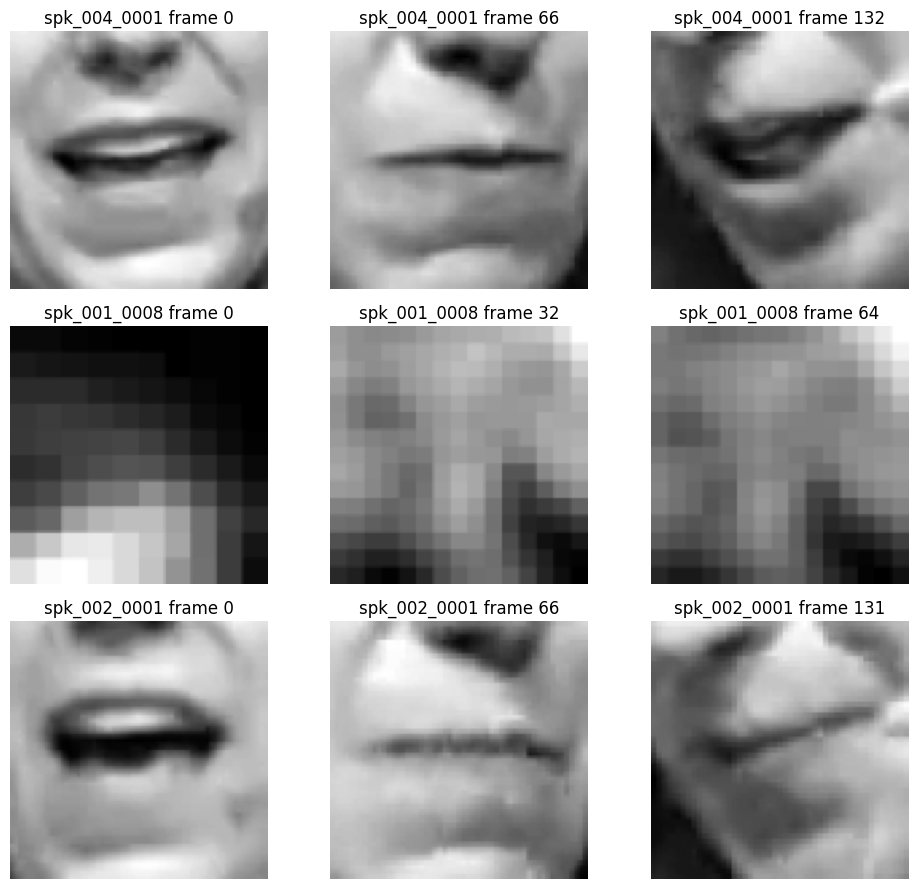

,split,clip_id,speaker_id,text,roi_path,roi_shape
0,train,spk_004_0001,spk_004,A few years ago when my husband was my boyfrie...,/home/shravan/Workspace/LipSynth/Pipeline/data...,"(133, 96, 96)"
1,val,spk_001_0008,spk_001,Here we see another horrible scene.,/home/shravan/Workspace/LipSynth/Pipeline/data...,"(65, 96, 96)"
2,test,spk_002_0001,spk_002,"A few years ago, when my husband was my boyfri...",/home/shravan/Workspace/LipSynth/Pipeline/data...,"(132, 96, 96)"


In [3]:
raw_train_df = pd.read_csv(DATA_DIR / 'train.tsv', sep='	')
raw_val_df = pd.read_csv(DATA_DIR / 'val.tsv', sep='	')
raw_test_df = pd.read_csv(DATA_DIR / 'test.tsv', sep='	')

split_summary_df = pd.DataFrame([
    {
        'split': 'train',
        'manifest_rows': len(raw_train_df),
        'active_rows': len(train_df),
        'active_speakers': train_df['speaker_id'].nunique(),
    },
    {
        'split': 'val',
        'manifest_rows': len(raw_val_df),
        'active_rows': len(val_df),
        'active_speakers': val_df['speaker_id'].nunique(),
    },
    {
        'split': 'test',
        'manifest_rows': len(raw_test_df),
        'active_rows': len(test_df),
        'active_speakers': test_df['speaker_id'].nunique(),
    },
])
display(split_summary_df)

speaker_counts_df = (
    pd.concat([
        train_df.assign(split='train'),
        val_df.assign(split='val'),
        test_df.assign(split='test'),
    ], ignore_index=True)
    .groupby('speaker_id')
    .agg(clips=('clip_id', 'count'), splits=('split', lambda s: ', '.join(sorted(set(s)))))
    .sort_values('clips', ascending=False)
    .head(10)
    .reset_index()
)
print('Top speakers by clip count in the active notebook subset:')
display(speaker_counts_df)

sample_rows = pd.concat([
    raw_train_df.head(1).assign(split='train'),
    raw_val_df.head(1).assign(split='val'),
    raw_test_df.head(1).assign(split='test'),
], ignore_index=True)

sample_records = []
fig, axes = plt.subplots(len(sample_rows), 3, figsize=(10, 3 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    clip_id = row['clip_id']
    speaker_id = row['speaker_id']
    roi_path = LIP_ROI_DIR / speaker_id / f'{clip_id}.npz'
    mouth_rois = np.load(roi_path)['mouth_rois']
    frame_ids = [0, len(mouth_rois) // 2, len(mouth_rois) - 1]
    sample_records.append({
        'split': row['split'],
        'clip_id': clip_id,
        'speaker_id': speaker_id,
        'text': row['text'],
        'roi_path': str(roi_path),
        'roi_shape': tuple(mouth_rois.shape),
    })
    for col_idx, frame_idx in enumerate(frame_ids):
        axes[row_idx, col_idx].imshow(mouth_rois[frame_idx], cmap='gray')
        axes[row_idx, col_idx].set_title(f"{clip_id} frame {frame_idx}")
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()
display(pd.DataFrame(sample_records))


## 3. LipVoicer Checkpoint Discovery and Model Construction

We implement a Stage 1 model with a LipVoicer-style stack:

- 3D CNN frontend
- sequence encoder (Transformer)
- CTC projection head

This is a pragmatic implementation for your data contract while preserving the expected Stage 1 behavior.

In [4]:
class Stage1LipVoicerCNNCTC(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 256, nhead: int = 8, num_layers: int = 4):
        super().__init__()
        self.vocab_size = vocab_size

        self.frontend3d = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=(5, 7, 7), stride=(1, 2, 2), padding=(2, 3, 3), bias=False),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
        )

        self.frame_encoder = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.proj = nn.Linear(256, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=0.1,
            batch_first=True,
            activation='gelu',
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ctc_head = nn.Linear(d_model, vocab_size)

    def forward(self, rois: torch.Tensor, roi_lens: torch.Tensor, return_features: bool = False):
        # rois: (B, 1, T, 96, 96)
        x = self.frontend3d(rois)  # (B, C, T, H, W)
        b, c, t, h, w = x.shape

        x = x.permute(0, 2, 1, 3, 4).contiguous().view(b * t, c, h, w)  # (B*T, C, H, W)
        x = self.frame_encoder(x).view(b, t, -1)  # (B, T, 256)
        x = self.proj(x)  # (B, T, d_model)

        max_t = x.size(1)
        key_padding_mask = torch.arange(max_t, device=x.device).unsqueeze(0) >= roi_lens.unsqueeze(1)
        x = self.temporal_encoder(x, src_key_padding_mask=key_padding_mask)

        logits = self.ctc_head(x)  # (B, T, vocab)
        if return_features:
            return logits, x
        return logits


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


model = Stage1LipVoicerCNNCTC(vocab_size=len(idx_to_token)).to(DEVICE)
print(model)
print(f'Trainable params: {count_params(model):,}')

Stage1LipVoicerCNNCTC(
  (frontend3d): Sequential(
    (0): Conv3d(1, 64, kernel_size=(5, 7, 7), stride=(1, 2, 2), padding=(2, 3, 3), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1), dilation=1, ceil_mode=False)
  )
  (frame_encoder): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (proj): Linear(in_features=256, out_features=256, bias=True)
  (temporal_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x Transf

## 4. Pretrained Weights Loading and Compatibility Checks

This section attempts to:

1. Clone official LipVoicer repo (`yochaiye/LipVoicer`) if missing.
2. Optionally run `download_checkpoints.py`.
3. Discover lip-reading checkpoints.
4. Load weights with strict/non-strict checks and report missing/unexpected keys.
5. Run a smoke forward pass.

In [5]:
def run_cmd(cmd: List[str], cwd: Optional[Path] = None):
    print('>>', ' '.join(cmd))
    subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=True)


def ensure_lipvoicer_repo(repo_dir: Path):
    if repo_dir.exists():
        print('LipVoicer repo exists:', repo_dir)
        return
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    run_cmd(['git', 'clone', 'https://github.com/yochaiye/LipVoicer.git', str(repo_dir)])


def maybe_download_lipvoicer_checkpoints(repo_dir: Path):
    script = repo_dir / 'download_checkpoints.py'
    if not script.exists():
        print('download_checkpoints.py not found, skipping')
        return
    run_cmd(['python3.12', str(script)], cwd=repo_dir)


def collect_checkpoint_candidates(repo_dir: Path) -> List[Path]:
    cands = [Path(p) for p in CONFIG['local_checkpoint_candidates']]

    visual_candidates = [
        repo_dir / 'mouthroi_processing' / 'benchmarks' / 'LRS3' / 'models' / 'LRS3_V_WER19.1' / 'model.pth',
    ]
    cands.extend(visual_candidates)

    uniq = []
    seen = set()
    for cand in cands:
        s = str(cand)
        if s not in seen:
            seen.add(s)
            uniq.append(cand)
    return uniq


def extract_state_dict(payload: Dict) -> Dict[str, torch.Tensor]:
    if isinstance(payload, dict):
        for key in ['state_dict', 'model_state_dict', 'model', 'net']:
            if key in payload and isinstance(payload[key], dict):
                return payload[key]
        if all(isinstance(v, torch.Tensor) for v in payload.values()):
            return payload
    raise ValueError('Could not find a compatible state dict in checkpoint payload')


def load_pretrained_weights(model: nn.Module, ckpt_path: Path):
    print('Loading checkpoint:', ckpt_path)
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    state = extract_state_dict(payload)

    remapped = {}
    for k, v in state.items():
        nk = k
        for prefix in ['module.', 'model.', 'net.']:
            if nk.startswith(prefix):
                nk = nk[len(prefix):]
        remapped[nk] = v

    missing, unexpected = model.load_state_dict(remapped, strict=False)
    is_compatible = len(missing) <= 5 and len(unexpected) <= 5
    print('Missing keys:', len(missing))
    print('Unexpected keys:', len(unexpected))
    if missing[:10]:
        print('Missing sample:', missing[:10])
    if unexpected[:10]:
        print('Unexpected sample:', unexpected[:10])
    print('Compatible with notebook model:', is_compatible)

    return {
        'missing': missing,
        'unexpected': unexpected,
        'loaded_keys': len(remapped),
        'is_compatible': is_compatible,
        'checkpoint_path': str(ckpt_path),
    }


lipvoicer_repo = Path(CONFIG['lipvoicer_repo_dir'])
if CONFIG['clone_lipvoicer_repo']:
    ensure_lipvoicer_repo(lipvoicer_repo)
if CONFIG['download_lipvoicer_checkpoints']:
    maybe_download_lipvoicer_checkpoints(lipvoicer_repo)

checkpoint_candidates = collect_checkpoint_candidates(lipvoicer_repo)
existing_candidates = [p for p in checkpoint_candidates if p.exists()]
print('Visual checkpoint candidates found:', len(existing_candidates))
for cand in existing_candidates:
    print('-', cand)

load_report = None
for cand in existing_candidates:
    try:
        report = load_pretrained_weights(model, cand)
    except Exception as exc:
        print(f'Skip {cand.name}: {exc}')
        continue
    if report['is_compatible']:
        load_report = report
        print('Loaded compatible notebook checkpoint from:', cand)
        break
    print('Rejected incompatible checkpoint for notebook experiments:', cand)

if load_report is None:
    print('No compatible visual checkpoint found for the notebook-local CNN+Transformer model.')

# Scripted pretrained baseline is authoritative.
scripted_output_dir = OUTPUT_DIR / 'pretrained'
scripted_output_dir.mkdir(parents=True, exist_ok=True)
scripted_summary_path = scripted_output_dir / 'val_summary_stage1_pretrained.json'
scripted_eval_cmd = [
    os.sys.executable,
    str(PIPELINE_ROOT / 'scripts' / 'stage1_pretrained_eval.py'),
    '--split', 'val',
    '--manifest-tsv', str(DATA_DIR / 'val.tsv'),
    '--lip-roi-root', str(LIP_ROI_DIR),
    '--output-dir', str(scripted_output_dir),
]
SCRIPTED_BASELINE_SUMMARY = None
SCRIPTED_BASELINE_PRED_PATH = None
should_run_scripted_baseline = CONFIG.get('force_scripted_baseline_refresh', False)

if not should_run_scripted_baseline and CONFIG.get('reuse_scripted_baseline_if_present', True) and scripted_summary_path.exists():
    cached_summary = json.loads(scripted_summary_path.read_text())
    cached_pred_csv = cached_summary.get('outputs', {}).get('predictions_csv')
    cached_pred_path = Path(cached_pred_csv) if cached_pred_csv else None
    if cached_pred_path and cached_pred_path.exists():
        SCRIPTED_BASELINE_SUMMARY = cached_summary
        SCRIPTED_BASELINE_PRED_PATH = cached_pred_path
        print('Using cached scripted pretrained baseline:', scripted_summary_path)
    else:
        should_run_scripted_baseline = True
        print('Cached scripted baseline is incomplete, rerunning:', scripted_summary_path)
else:
    should_run_scripted_baseline = True

if should_run_scripted_baseline:
    print('Running authoritative scripted pretrained baseline...')
    scripted_result = subprocess.run(scripted_eval_cmd, capture_output=True, text=True, cwd=str(PIPELINE_ROOT))
    print(scripted_result.stdout)
    if scripted_result.returncode != 0:
        tail = scripted_result.stderr[-4000:] if scripted_result.stderr else '<no stderr>'
        raise RuntimeError(f'Scripted Stage 1 baseline failed.\n\n{tail}')
    if not scripted_summary_path.exists():
        raise FileNotFoundError(f'Missing scripted summary: {scripted_summary_path}')
    SCRIPTED_BASELINE_SUMMARY = json.loads(scripted_summary_path.read_text())
    SCRIPTED_BASELINE_PRED_PATH = Path(SCRIPTED_BASELINE_SUMMARY['outputs']['predictions_csv'])

if SCRIPTED_BASELINE_SUMMARY is None or SCRIPTED_BASELINE_PRED_PATH is None:
    raise RuntimeError('Scripted pretrained baseline was neither loaded from cache nor regenerated.')
print(json.dumps(SCRIPTED_BASELINE_SUMMARY, indent=2)[:2000])

# Smoke forward only for notebook experiments.
batch = next(iter(val_loader))
rois = batch['rois'].to(DEVICE)
roi_lens = batch['roi_lens'].to(DEVICE)
with torch.no_grad():
    logits, feats = model(rois, roi_lens, return_features=True)
print('Smoke logits shape:', tuple(logits.shape))
print('Smoke feature shape:', tuple(feats.shape))
assert logits.shape[-1] == len(idx_to_token), 'Output vocab dimension mismatch'


LipVoicer repo exists: /home/shravan/Workspace/LipSynth/Pipeline/third_party/LipVoicer
Visual checkpoint candidates found: 1
- /home/shravan/Workspace/LipSynth/Pipeline/third_party/LipVoicer/mouthroi_processing/benchmarks/LRS3/models/LRS3_V_WER19.1/model.pth
Loading checkpoint: /home/shravan/Workspace/LipSynth/Pipeline/third_party/LipVoicer/mouthroi_processing/benchmarks/LRS3/models/LRS3_V_WER19.1/model.pth
Missing keys: 69
Unexpected keys: 767
Missing sample: ['frontend3d.0.weight', 'frontend3d.1.weight', 'frontend3d.1.bias', 'frontend3d.1.running_mean', 'frontend3d.1.running_var', 'frame_encoder.0.weight', 'frame_encoder.0.bias', 'frame_encoder.1.weight', 'frame_encoder.1.bias', 'frame_encoder.1.running_mean']
Unexpected sample: ['encoder.frontend.trunk.layer1.0.conv1.weight', 'encoder.frontend.trunk.layer1.0.bn1.weight', 'encoder.frontend.trunk.layer1.0.bn1.bias', 'encoder.frontend.trunk.layer1.0.bn1.running_mean', 'encoder.frontend.trunk.layer1.0.bn1.running_var', 'encoder.frontend

## 5. Inference Pipeline (Greedy/Beam CTC Decode)

We run Stage 1 inference on validation clips and decode CTC outputs.

- Greedy decoding is enabled by default.
- Beam decoding hook is included and can be enabled later (for `pyctcdecode`).

In [6]:
@torch.no_grad()
def greedy_ctc_decode(logits: torch.Tensor, blank: int = 0) -> List[List[int]]:
    pred = logits.argmax(dim=-1).cpu().numpy()
    decoded = []
    for seq in pred:
        out = []
        prev = None
        for token in seq:
            token = int(token)
            if token != blank and token != prev:
                out.append(token)
            prev = token
        decoded.append(out)
    return decoded


def confidence_from_logits(logits: torch.Tensor, blank: int = 0) -> Tuple[np.ndarray, List[List[float]]]:
    probs = torch.softmax(logits, dim=-1)
    max_probs, max_ids = probs.max(dim=-1)
    seq_conf = max_probs.mean(dim=-1).detach().cpu().numpy()

    token_conf_all = []
    max_ids_np = max_ids.detach().cpu().numpy()
    max_probs_np = max_probs.detach().cpu().numpy()
    for ids, ps in zip(max_ids_np, max_probs_np):
        confs = []
        prev = None
        for tid, p in zip(ids.tolist(), ps.tolist()):
            if tid != blank and tid != prev:
                confs.append(float(p))
            prev = tid
        token_conf_all.append(confs)
    return seq_conf, token_conf_all


def normalize_prediction_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r'\s+', ' ', s)
    return s


USING_SCRIPTED_BASELINE = SCRIPTED_BASELINE_PRED_PATH.exists()
if USING_SCRIPTED_BASELINE:
    pred_df = pd.read_csv(SCRIPTED_BASELINE_PRED_PATH, keep_default_na=False)
    print('Using scripted pretrained baseline predictions for notebook analysis.')
else:
    if load_report is None or not load_report.get('is_compatible', False):
        raise RuntimeError(
            'No compatible notebook-local checkpoint is loaded and no scripted baseline predictions are available.'
        )

    model.eval()
    rows = []
    for batch in tqdm(val_loader, desc='Stage1 notebook inference'):
        rois = batch['rois'].to(DEVICE)
        roi_lens = batch['roi_lens'].to(DEVICE)

        logits, feats = model(rois, roi_lens, return_features=True)
        decoded_ids = greedy_ctc_decode(logits, blank=blank_id)
        seq_conf, token_conf = confidence_from_logits(logits, blank=blank_id)

        for i in range(len(batch['clip_id'])):
            pred_text = normalize_prediction_text(decode_ids(decoded_ids[i]))
            gt_text = normalize_prediction_text(batch['text'][i])
            rows.append({
                'clip_id': batch['clip_id'][i],
                'speaker_id': batch['speaker_id'][i],
                'roi_path': batch['roi_path'][i],
                'gt_text': gt_text,
                'pred_text': pred_text,
                'pred_token_ids': decoded_ids[i],
                'token_confidence': token_conf[i],
                'sequence_confidence': float(seq_conf[i]),
            })
    pred_df = pd.DataFrame(rows)

for col in ['gt_text', 'pred_text']:
    pred_df[col] = pred_df[col].fillna('').astype(str).map(normalize_prediction_text)

print('Predictions:', len(pred_df))
pred_df.head(5)


Using scripted pretrained baseline predictions for notebook analysis.
Predictions: 729


,clip_id,speaker_id,roi_path,gt_text,pred_text,sequence_confidence,confidence_type,decoder_name,beam_score,raw_roi_shape,transformed_roi_shape,cer,wer
0,spk_001_0008,spk_001,/home/shravan/Workspace/LipSynth/Pipeline/data...,here we see another horrible scene.,that's what i'm going to do,0.289894,beam_score_proxy,batch_beam_search_ctc_lm,-23.826408,"[65, 96, 96]","[1, 65, 88, 88]",0.828571,1.0
1,spk_001_0009,spk_001,/home/shravan/Workspace/LipSynth/Pipeline/data...,horrors of war. these are some austrian killin...,that's what i'm going to do,0.911203,beam_score_proxy,batch_beam_search_ctc_lm,-25.288906,"[109, 96, 96]","[1, 109, 88, 88]",0.789474,1.0
2,spk_001_0011,spk_001,/home/shravan/Workspace/LipSynth/Pipeline/data...,ostrians and serbians could be anybody.,that's why i'm here,0.521183,beam_score_proxy,batch_beam_search_ctc_lm,-21.681982,"[54, 96, 96]","[1, 54, 88, 88]",0.820513,1.0
3,spk_001_0019,spk_001,/home/shravan/Workspace/LipSynth/Pipeline/data...,"well, i perhaps you are thinking of some answers.",and i'm going to thank you very much,0.742579,beam_score_proxy,batch_beam_search_ctc_lm,-16.166140,"[63, 96, 96]","[1, 63, 88, 88]",0.755102,1.0
4,spk_001_0020,spk_001,/home/shravan/Workspace/LipSynth/Pipeline/data...,there are many answers that are suggested for ...,i'm not going to say that i'm not going to,0.781543,beam_score_proxy,batch_beam_search_ctc_lm,-30.486012,"[113, 96, 96]","[1, 113, 88, 88]",0.727273,1.0


## 6. Baseline Evaluation on Validation Split (WER/CER)

Compute aggregate and per-speaker quality for Stage 1 predictions.

In [7]:
for col in ['gt_text', 'pred_text']:
    pred_df[col] = pred_df[col].fillna('').astype(str).map(normalize_prediction_text)

empty_pred_count = int(pred_df['pred_text'].eq('').sum())
if empty_pred_count:
    print(f'Empty predictions: {empty_pred_count}')

def cer_one(ref: str, hyp: str) -> float:
    return jiwer.cer(ref, hyp)


def wer_one(ref: str, hyp: str) -> float:
    return jiwer.wer(ref, hyp)


pred_df['cer'] = [cer_one(r, h) for r, h in zip(pred_df['gt_text'], pred_df['pred_text'])]
pred_df['wer'] = [wer_one(r, h) for r, h in zip(pred_df['gt_text'], pred_df['pred_text'])]

overall_wer = jiwer.wer(pred_df['gt_text'].tolist(), pred_df['pred_text'].tolist())
overall_cer = jiwer.cer(pred_df['gt_text'].tolist(), pred_df['pred_text'].tolist())

print(f'Overall WER: {overall_wer:.4f}')
print(f'Overall CER: {overall_cer:.4f}')

speaker_metrics = pred_df.groupby('speaker_id', as_index=False).agg(
    n=('clip_id', 'count'),
    wer=('wer', 'mean'),
    cer=('cer', 'mean'),
    confidence=('sequence_confidence', 'mean'),
).sort_values('wer', ascending=False)

print('\nPer-speaker metrics:')
display(speaker_metrics)

hardest = pred_df.sort_values(['wer', 'cer'], ascending=False).head(20)
print('\nHardest clips:')
display(hardest[['clip_id', 'speaker_id', 'gt_text', 'pred_text', 'wer', 'cer', 'sequence_confidence']])

pred_path = OUTPUT_DIR / 'val_predictions_stage1.csv'
pred_df.to_csv(pred_path, index=False)
print('Saved:', pred_path)

Empty predictions: 1
Overall WER: 0.8830
Overall CER: 0.6426

Per-speaker metrics:


,speaker_id,n,wer,cer,confidence
0,spk_001,75,1.048034,0.726930,0.688403
6,spk_036,73,0.973039,0.679859,0.659214
4,spk_029,146,0.944231,0.714085,0.599714
7,spk_043,50,0.915129,0.642056,0.636859
3,spk_020,130,0.870228,0.613648,0.579810
1,spk_003,108,0.849049,0.639554,0.656411
5,spk_033,78,0.841074,0.613115,0.571980
2,spk_017,69,0.679041,0.482214,0.603482



Hardest clips:


,clip_id,speaker_id,gt_text,pred_text,wer,cer,sequence_confidence
33,spk_001_0053,spk_001,so competition drives cooperation.,in the wrong position you have all the relation,2.250000,0.882353,0.686686
71,spk_001_0104,spk_001,"another one is environmental destruction,",what i'm going to do is i'm going to make frie...,2.200000,1.024390,0.297942
335,spk_020_0084,spk_020,these aren't fringe behaviors that have existe...,i don't know what i'm going to do but i'm goin...,1.777778,0.887097,0.706959
672,spk_036_0091,spk_036,"system. where exercise isn't optional, it's in...",that's that's that's that's that's that's that...,1.750000,0.956044,0.728429
344,spk_020_0093,spk_020,"calabas chalk causes pre-tambourth,",my children who did not preach above,1.750000,0.857143,0.999242
345,spk_020_0094,spk_020,"infertility, particularly secondary infertility,",emphasizing what's going on inside the universe,1.750000,0.833333,0.531881
49,spk_001_0072,spk_001,"correct, violence is violence that is premedit...",more like a face and a face and more like a face,1.714286,0.784314,0.499216
610,spk_036_0009,spk_036,"i built a life around movement,",i'm going to tell you i'm going to tell you,1.666667,1.000000,0.882375
622,spk_036_0024,spk_036,32%. my brain couldn't stop calculating.,the list goes on and on and on and on,1.666667,0.850000,0.863111
139,spk_003_0070,spk_003,we obsess over our outcomes like the promotion...,and that's what i'm going to do i'm going to d...,1.666667,0.821053,0.826761


Saved: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/val_predictions_stage1.csv


## 7. Confidence Score Extraction and Calibration

We derive confidence $c \in [0,1]$, test if it correlates with errors, and optionally fit isotonic calibration.

Spearman(confidence, CER): 0.2343
ECE (exact-match proxy): 0.6196


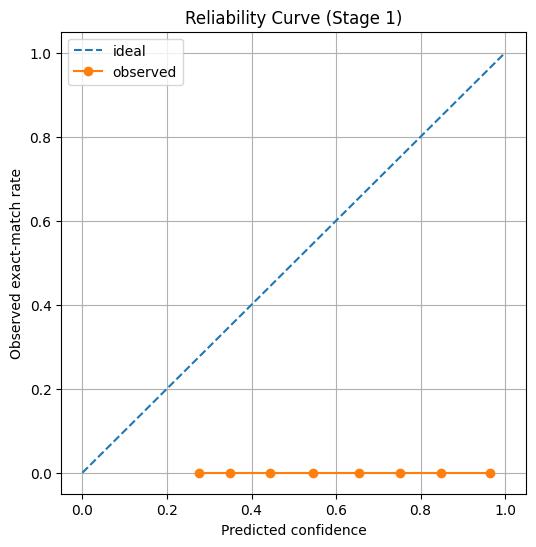

Isotonic calibration fitted.


In [8]:
pred_df['is_exact'] = (pred_df['cer'] == 0.0).astype(float)

corr = pred_df['sequence_confidence'].corr(pred_df['cer'], method='spearman')
print(f'Spearman(confidence, CER): {corr:.4f}')

# Reliability curve bins
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
pred_df['conf_bin'] = pd.cut(pred_df['sequence_confidence'], bins=bins, include_lowest=True)
rel = pred_df.groupby('conf_bin', observed=False).agg(
    avg_conf=('sequence_confidence', 'mean'),
    acc=('is_exact', 'mean'),
    n=('clip_id', 'count'),
).reset_index(drop=True)

rel = rel.dropna()
if len(rel) > 0:
    ece = np.sum(np.abs(rel['avg_conf'] - rel['acc']) * (rel['n'] / rel['n'].sum()))
else:
    ece = np.nan
print(f'ECE (exact-match proxy): {ece:.4f}')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', label='ideal')
if len(rel) > 0:
    plt.plot(rel['avg_conf'], rel['acc'], marker='o', label='observed')
plt.xlabel('Predicted confidence')
plt.ylabel('Observed exact-match rate')
plt.title('Reliability Curve (Stage 1)')
plt.legend()
plt.grid(True)
plt.show()

# Optional isotonic calibration if sklearn available
if IsotonicRegression is not None and len(pred_df) >= 20:
    iso = IsotonicRegression(out_of_bounds='clip')
    x = pred_df['sequence_confidence'].to_numpy()
    y = pred_df['is_exact'].to_numpy()
    iso.fit(x, y)
    pred_df['sequence_conf_calibrated'] = iso.predict(x)
    print('Isotonic calibration fitted.')
else:
    pred_df['sequence_conf_calibrated'] = pred_df['sequence_confidence']
    print('Isotonic not available or insufficient data; using raw confidence.')

## 8. Error Bucketing for Stage 1 Failures

We group failures by confidence, sequence length, and speaker to expose where Stage 1 breaks.

In [9]:
# Attach frame lengths for analysis
val_len_map = {row['clip_id']: np.load(LIP_ROI_DIR / row['speaker_id'] / f"{row['clip_id']}.npz")['mouth_rois'].shape[0]
               for _, row in val_df.iterrows()}
pred_df['n_frames'] = pred_df['clip_id'].map(val_len_map)

# Buckets
pred_df['len_bucket'] = pd.cut(pred_df['n_frames'], bins=[0, 60, 100, 160, 10_000], labels=['short', 'mid', 'long', 'xlong'])
pred_df['conf_bucket'] = pd.cut(pred_df['sequence_confidence'], bins=[0.0, 0.4, 0.6, 0.8, 1.0], labels=['very_low', 'low', 'mid', 'high'], include_lowest=True)
pred_df['high_cer'] = pred_df['cer'] >= pred_df['cer'].quantile(0.75)

bucket_summary = pred_df.groupby(['speaker_id', 'len_bucket', 'conf_bucket'], observed=False).agg(
    n=('clip_id', 'count'),
    avg_wer=('wer', 'mean'),
    avg_cer=('cer', 'mean')
).reset_index().sort_values(['avg_wer', 'n'], ascending=[False, False])

display(bucket_summary.head(30))

error_buckets_path = OUTPUT_DIR / 'stage1_error_buckets.csv'
bucket_summary.to_csv(error_buckets_path, index=False)
print('Saved:', error_buckets_path)

,speaker_id,len_bucket,conf_bucket,n,avg_wer,avg_cer
4,spk_001,mid,very_low,3,1.400000,0.870987
5,spk_001,mid,low,7,1.191327,0.779915
16,spk_003,short,very_low,1,1.142857,0.688889
6,spk_001,mid,mid,9,1.127020,0.775142
7,spk_001,mid,high,4,1.125000,0.800280
10,spk_001,long,mid,8,1.084388,0.748257
25,spk_003,long,low,3,1.070054,0.749067
13,spk_001,xlong,low,3,1.025641,0.657414
15,spk_001,xlong,high,9,1.009832,0.727726
11,spk_001,long,high,15,0.990288,0.710707


Saved: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/stage1_error_buckets.csv


## 9. Quick Fine-Tuning Experiment (Optional)

This short experiment compares:

- pretrained-only
- head-only tuning
- full model tuning

Set `RUN_FINETUNE = False` only if a compatible pretrained checkpoint was loaded and GPU is available.


In [10]:
RUN_FINETUNE = True
MAX_STEPS = 80
LR = 2e-4

ctc_loss_fn = nn.CTCLoss(blank=blank_id, zero_infinity=True)


def train_one_epoch_stage1(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, max_steps: int = 80):
    model.train()
    losses = []
    step = 0
    for batch in loader:
        rois = batch['rois'].to(DEVICE)
        roi_lens = batch['roi_lens'].to(DEVICE)
        tgt = batch['token_ids'].to(DEVICE)
        tgt_lens = batch['token_lens'].to(DEVICE)

        logits = model(rois, roi_lens)  # (B,T,V)
        log_probs = F.log_softmax(logits, dim=-1).transpose(0, 1)  # (T,B,V)

        input_lens = roi_lens
        targets_flat = torch.cat([tgt[i, :tgt_lens[i]] for i in range(tgt.size(0))])

        loss = ctc_loss_fn(log_probs, targets_flat, input_lens, tgt_lens)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        losses.append(float(loss.item()))
        step += 1
        if step >= max_steps:
            break

    return float(np.mean(losses)) if losses else np.nan


if RUN_FINETUNE:
    for name, p in model.named_parameters():
        p.requires_grad = True

    # Example freeze plan: only CTC head + transformer
    # for name, p in model.named_parameters():
    #     if not (name.startswith('temporal_encoder') or name.startswith('ctc_head') or name.startswith('proj')):
    #         p.requires_grad = False

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    train_loss = train_one_epoch_stage1(model, train_loader, optimizer, max_steps=MAX_STEPS)
    print(f'Quick fine-tune train loss: {train_loss:.4f}')

    tuned_ckpt = OUTPUT_DIR / 'stage1_quick_finetuned.pt'
    torch.save({'model_state_dict': model.state_dict()}, tuned_ckpt)
    print('Saved quick tuned checkpoint:', tuned_ckpt)
else:
    print('RUN_FINETUNE=False, skipped quick tuning experiment.')

Quick fine-tune train loss: 3.1103
Saved quick tuned checkpoint: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/stage1_quick_finetuned.pt


## 9.1 Quick Fine-Tune Validation Eval

Evaluate the quick-tuned notebook CTC checkpoint against the same validation split and compare it with the authoritative pretrained AVSR baseline.

In [11]:
QUICK_FT_CKPT = OUTPUT_DIR / 'stage1_quick_finetuned.pt'
QUICK_FT_EVAL_MAX_BATCHES = None  # Set to a small integer for a smoke eval.


def evaluate_stage1_ctc_checkpoint(ckpt_path: Path, loader: DataLoader, max_batches: Optional[int] = None):
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Quick fine-tuned checkpoint not found: {ckpt_path}')

    payload = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    state_dict = payload.get('model_state_dict', payload)

    eval_model = Stage1LipVoicerCNNCTC(vocab_size=len(idx_to_token)).to(DEVICE)
    eval_model.load_state_dict(state_dict, strict=True)
    eval_model.eval()

    rows = []
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(loader, desc='Quick fine-tuned val eval')):
            if max_batches is not None and batch_idx >= max_batches:
                break

            rois = batch['rois'].to(DEVICE)
            roi_lens = batch['roi_lens'].to(DEVICE)
            logits, feats = eval_model(rois, roi_lens, return_features=True)
            decoded_ids = greedy_ctc_decode(logits, blank=blank_id)
            seq_conf, token_conf = confidence_from_logits(logits, blank=blank_id)

            for i in range(len(batch['clip_id'])):
                rows.append({
                    'clip_id': batch['clip_id'][i],
                    'speaker_id': batch['speaker_id'][i],
                    'roi_path': batch['roi_path'][i],
                    'gt_text': normalize_prediction_text(batch['text'][i]),
                    'pred_text': normalize_prediction_text(decode_ids(decoded_ids[i])),
                    'pred_token_ids': decoded_ids[i],
                    'token_confidence': token_conf[i],
                    'sequence_confidence': float(seq_conf[i]),
                })

    eval_df = pd.DataFrame(rows)
    for col in ['gt_text', 'pred_text']:
        eval_df[col] = eval_df[col].fillna('').astype(str).map(normalize_prediction_text)

    eval_df['cer'] = [float(jiwer.cer(r, h)) for r, h in zip(eval_df['gt_text'], eval_df['pred_text'])]
    eval_df['wer'] = [float(jiwer.wer(r, h)) for r, h in zip(eval_df['gt_text'], eval_df['pred_text'])]

    overall_wer_quick = float(jiwer.wer(eval_df['gt_text'].tolist(), eval_df['pred_text'].tolist()))
    overall_cer_quick = float(jiwer.cer(eval_df['gt_text'].tolist(), eval_df['pred_text'].tolist()))
    baseline_wer = np.nan
    baseline_cer = np.nan
    baseline_source = None
    if 'SCRIPTED_BASELINE_PRED_PATH' in globals() and SCRIPTED_BASELINE_PRED_PATH.exists():
        baseline_df = pd.read_csv(SCRIPTED_BASELINE_PRED_PATH, keep_default_na=False)
        baseline_df = baseline_df[baseline_df['clip_id'].isin(eval_df['clip_id'])].copy()
        baseline_df = baseline_df.set_index('clip_id').loc[eval_df['clip_id']].reset_index()
        for col in ['gt_text', 'pred_text']:
            baseline_df[col] = baseline_df[col].fillna('').astype(str).map(normalize_prediction_text)
        baseline_wer = float(jiwer.wer(baseline_df['gt_text'].tolist(), baseline_df['pred_text'].tolist()))
        baseline_cer = float(jiwer.cer(baseline_df['gt_text'].tolist(), baseline_df['pred_text'].tolist()))
        baseline_source = str(SCRIPTED_BASELINE_PRED_PATH)
    elif 'SCRIPTED_BASELINE_SUMMARY' in globals():
        baseline_wer = float(SCRIPTED_BASELINE_SUMMARY['overall_wer'])
        baseline_cer = float(SCRIPTED_BASELINE_SUMMARY['overall_cer'])
        baseline_source = str(scripted_summary_path) if 'scripted_summary_path' in globals() else None
    train_loss_value = globals().get('train_loss')
    train_loss_out = None if train_loss_value is None or np.isnan(train_loss_value) else float(train_loss_value)

    pred_path = OUTPUT_DIR / 'val_predictions_stage1_quick_finetuned.csv'
    summary_path = OUTPUT_DIR / 'val_summary_stage1_quick_finetuned.json'
    eval_df.to_csv(pred_path, index=False)

    summary = {
        'checkpoint': str(ckpt_path),
        'num_predictions': int(len(eval_df)),
        'max_batches': max_batches,
        'train_loss': train_loss_out,
        'overall_wer': overall_wer_quick,
        'overall_cer': overall_cer_quick,
        'mean_sequence_confidence': float(eval_df['sequence_confidence'].mean()),
        'empty_predictions': int(eval_df['pred_text'].eq('').sum()),
        'baseline_source': baseline_source,
        'baseline_pretrained_wer': None if np.isnan(baseline_wer) else baseline_wer,
        'baseline_pretrained_cer': None if np.isnan(baseline_cer) else baseline_cer,
        'wer_delta_vs_pretrained': None if np.isnan(baseline_wer) else overall_wer_quick - baseline_wer,
        'cer_delta_vs_pretrained': None if np.isnan(baseline_cer) else overall_cer_quick - baseline_cer,
        'beats_pretrained': False if np.isnan(baseline_wer) else overall_wer_quick < baseline_wer,
        'outputs': {'predictions_csv': str(pred_path)},
    }
    summary_path.write_text(json.dumps(summary, indent=2))

    print(f'Quick fine-tuned WER: {overall_wer_quick:.4f}')
    print(f'Quick fine-tuned CER: {overall_cer_quick:.4f}')
    if not np.isnan(baseline_wer):
        print(f'Pretrained baseline WER: {baseline_wer:.4f}')
        print(f'WER delta vs pretrained: {overall_wer_quick - baseline_wer:+.4f}')
    print('Saved predictions:', pred_path)
    print('Saved summary:', summary_path)
    return eval_df, summary


quick_ft_pred_df, quick_ft_summary = evaluate_stage1_ctc_checkpoint(
    QUICK_FT_CKPT,
    val_loader,
    max_batches=QUICK_FT_EVAL_MAX_BATCHES,
)
display(quick_ft_pred_df[['clip_id', 'gt_text', 'pred_text', 'wer', 'cer', 'sequence_confidence']].head(10))
quick_ft_summary


Quick fine-tuned val eval:   0%|          | 0/30 [00:00<?, ?it/s]

/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Quick fine-tuned WER: 1.0000
Quick fine-tuned CER: 0.9848
Pretrained baseline WER: 0.9352
WER delta vs pretrained: +0.0648
Saved predictions: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/val_predictions_stage1_quick_finetuned.csv
Saved summary: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/val_summary_stage1_quick_finetuned.json


,clip_id,gt_text,pred_text,wer,cer,sequence_confidence
0,spk_001_0008,here we see another horrible scene.,..i,1.0,0.971429,0.200858
1,spk_001_0009,horrors of war. these are some austrian killin...,.,1.0,0.982456,0.360158
2,spk_001_0011,ostrians and serbians could be anybody.,.i,1.0,0.974359,0.181921
3,spk_001_0019,"well, i perhaps you are thinking of some answers.",.i,1.0,0.979592,0.220602
4,spk_001_0020,there are many answers that are suggested for ...,.i,1.0,0.981818,0.311607
5,spk_001_0021,"evil leaders, religious hatred,",.i,1.0,0.967742,0.230215
6,spk_001_0022,or perhaps countries just want to conquer othe...,.,1.0,0.988095,0.387398
7,spk_001_0023,i think all of these different reasons and you...,.i,1.0,0.986486,0.344909
8,spk_001_0024,they all point in one direction.,.i,1.0,0.968750,0.154864
9,spk_001_0025,it's something to do with human nature.,.i,1.0,0.974359,0.183731


{'checkpoint': '/home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/stage1_quick_finetuned.pt',
 'num_predictions': 120,
 'max_batches': None,
 'train_loss': 3.1103243052959444,
 'overall_wer': 1.0,
 'overall_cer': 0.9847753434831044,
 'mean_sequence_confidence': 0.27855847651759785,
 'empty_predictions': 0,
 'baseline_source': '/home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/pretrained/val_predictions_stage1_pretrained.csv',
 'baseline_pretrained_wer': 0.9351789331532748,
 'baseline_pretrained_cer': 0.6828815447456368,
 'wer_delta_vs_pretrained': 0.06482106684672517,
 'cer_delta_vs_pretrained': 0.3018937987374676,
 'beats_pretrained': False,
 'outputs': {'predictions_csv': '/home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/val_predictions_stage1_quick_finetuned.csv'}}

## 10. Retrain-vs-Reuse Decision Matrix and Next Actions

Use measured metrics + calibration quality to choose one path:

- **Reuse pretrained** if WER/CER are already acceptable and confidence is calibrated.
- **Fine-tune** if model is close but domain mismatch remains.
- **Retrain** if performance is poor or no compatible checkpoint can be loaded.

This section also exports Stage 2-required fields:

- `clip_id`
- `predicted_tokens`
- `token_confidence`
- optional `visual_embedding_path` (placeholder)

In [12]:
def decide_action(wer: float, cer: float, ece_value: float, loaded_checkpoint: bool) -> str:
    if loaded_checkpoint and wer <= 0.35 and cer <= 0.20 and (np.isnan(ece_value) or ece_value <= 0.12):
        return 'reuse_pretrained'
    if loaded_checkpoint and wer <= 0.65:
        return 'finetune'
    return 'retrain'


if USING_SCRIPTED_BASELINE:
    action = SCRIPTED_BASELINE_SUMMARY['decision']
    rationale = SCRIPTED_BASELINE_SUMMARY['rationale']
    overall_wer = float(SCRIPTED_BASELINE_SUMMARY['overall_wer'])
    overall_cer = float(SCRIPTED_BASELINE_SUMMARY['overall_cer'])
    ece = np.nan
    loaded_checkpoint = True
    print('Decision (authoritative scripted baseline):', action)
    print('Rationale:', rationale)
    print('Scripted summary path:', scripted_summary_path)
    print('Scripted Stage-2 handoff:', SCRIPTED_BASELINE_SUMMARY['outputs']['stage2_handoff_csv'])

    notebook_summary = {
        'analysis_source': str(SCRIPTED_BASELINE_PRED_PATH),
        'scripted_summary_path': str(scripted_summary_path),
        'overall_wer': float(overall_wer),
        'overall_cer': float(overall_cer),
        'ece': None if np.isnan(ece) else float(ece),
        'loaded_checkpoint': bool(loaded_checkpoint),
        'decision': action,
        'rationale': rationale,
    }
    summary_path = OUTPUT_DIR / 'stage1_notebook_analysis_summary.json'
    summary_path.write_text(json.dumps(notebook_summary, indent=2))
    print('Saved notebook analysis summary:', summary_path)
    notebook_summary
else:
    loaded_checkpoint = load_report is not None and load_report.get('is_compatible', False)
    action = decide_action(overall_wer, overall_cer, ece, loaded_checkpoint)
    print('Decision:', action)

    if action == 'reuse_pretrained':
        rationale = 'Pretrained Stage 1 is already within target range on validation.'
    elif action == 'finetune':
        rationale = 'Checkpoint is promising but domain mismatch remains; run focused fine-tuning.'
    else:
        rationale = 'No compatible/strong checkpoint behavior; retrain Stage 1 with stronger supervision and augmentation.'

    print('Rationale:', rationale)

    if {'pred_token_ids', 'token_confidence'}.issubset(pred_df.columns):
        handoff = pred_df[['clip_id', 'pred_token_ids', 'token_confidence', 'sequence_conf_calibrated']].copy()
        handoff = handoff.rename(columns={
            'pred_token_ids': 'predicted_tokens',
            'sequence_conf_calibrated': 'token_confidence_calibrated',
        })
        handoff['visual_embedding_path'] = ''
        handoff_path = OUTPUT_DIR / 'stage1_outputs_for_stage2.csv'
        handoff.to_csv(handoff_path, index=False)
        print('Saved Stage-2 handoff:', handoff_path)

    summary = {
        'overall_wer': float(overall_wer),
        'overall_cer': float(overall_cer),
        'ece': None if np.isnan(ece) else float(ece),
        'loaded_checkpoint': bool(loaded_checkpoint),
        'decision': action,
        'rationale': rationale,
    }
    summary_path = OUTPUT_DIR / 'stage1_decision_summary.json'
    summary_path.write_text(json.dumps(summary, indent=2))
    print('Saved summary:', summary_path)
    summary


Decision (authoritative scripted baseline): retrain
Rationale: Pretrained Stage 1 is not strong enough on this domain, so the repo-native training path should become the primary Stage 1 track.
Scripted summary path: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/pretrained/val_summary_stage1_pretrained.json
Scripted Stage-2 handoff: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/pretrained/val_stage2_handoff_pretrained.csv
Saved notebook analysis summary: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/stage1_notebook_analysis_summary.json


## 11. Stage 1 Retraining Track

Use the scriptable retraining path when the pretrained baseline is not good enough for this dataset.

This remains Stage 1 work because the job is still `lips -> text`.


In [ ]:
STAGE1_RETRAIN_SCRIPT = PIPELINE_ROOT / 'scripts' / 'stage1_train_ctc.py'
RUN_RETRAIN_SMOKE = False
RUN_RETRAIN_FULL = True
REUSE_RETRAIN_RUNS_IF_PRESENT = True
FORCE_RETRAIN_RERUN = False

retrain_smoke_dir = OUTPUT_DIR / 'retrain_smoke'
retrain_full_dir = OUTPUT_DIR / 'retrain'


def retrain_summary_path(output_dir: Path) -> Path:
    return output_dir / 'val_summary_stage1_retrain.json'


def retrain_run_complete(output_dir: Path) -> bool:
    summary_path = retrain_summary_path(output_dir)
    if not summary_path.exists():
        return False
    try:
        summary = json.loads(summary_path.read_text())
    except json.JSONDecodeError:
        return False
    outputs = summary.get('outputs', {})
    pred_csv = outputs.get('predictions_csv')
    ckpt_path = outputs.get('selected_checkpoint') or outputs.get('best_checkpoint') or outputs.get('last_checkpoint')
    return bool(pred_csv and Path(pred_csv).exists() and ckpt_path and Path(ckpt_path).exists())


def find_retrain_resume_checkpoint(output_dir: Path) -> Optional[Path]:
    candidates = [
        output_dir / 'stage1_ctc_last.pt',
        output_dir / 'stage1_ctc_best.pt',
    ]
    return next((cand for cand in candidates if cand.exists()), None)


def run_stage1_retrain_command(cmd: List[str], label: str):
    print(f'Running {label}:')
    print(' '.join(cmd))
    result = subprocess.run(cmd, cwd=str(PIPELINE_ROOT), text=True, capture_output=True)
    if result.stdout:
        print(result.stdout[-4000:])
    if result.returncode != 0:
        print(result.stderr[-4000:] if result.stderr else '<no stderr>')
        raise RuntimeError(f'{label} failed with exit code {result.returncode}')
    return result


def maybe_run_stage1_retrain(cmd: List[str], label: str, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    summary_path = retrain_summary_path(output_dir)
    if REUSE_RETRAIN_RUNS_IF_PRESENT and not FORCE_RETRAIN_RERUN and retrain_run_complete(output_dir):
        print(f'Using cached {label}:', summary_path)
        return json.loads(summary_path.read_text())

    effective_cmd = list(cmd)
    if not FORCE_RETRAIN_RERUN:
        resume_ckpt = find_retrain_resume_checkpoint(output_dir)
        if resume_ckpt is not None:
            effective_cmd.extend(['--resume-checkpoint', str(resume_ckpt)])
            print(f'Resuming {label} from:', resume_ckpt)

    run_stage1_retrain_command(effective_cmd, label)
    if not summary_path.exists():
        raise FileNotFoundError(f'Missing retrain summary after {label}: {summary_path}')
    return json.loads(summary_path.read_text())


if RUN_RETRAIN_SMOKE:
    smoke_cmd = [
        os.sys.executable,
        str(STAGE1_RETRAIN_SCRIPT),
        '--epochs', '1',
        '--max-train-samples', '8',
        '--max-val-samples', '4',
        '--max-steps-per-epoch', '1',
        '--batch-size', '2',
        '--output-dir', str(retrain_smoke_dir),
    ]
    maybe_run_stage1_retrain(smoke_cmd, 'Stage 1 retrain smoke', retrain_smoke_dir)

if RUN_RETRAIN_FULL:
    full_cmd = [
        os.sys.executable,
        str(STAGE1_RETRAIN_SCRIPT),
        '--epochs', '20',
        '--augment',
        '--batch-size', '4',
        '--patience', '5',
        '--output-dir', str(retrain_full_dir),
    ]
    maybe_run_stage1_retrain(full_cmd, 'Stage 1 full retrain', retrain_full_dir)

print('Smoke output dir:', retrain_smoke_dir)
print('Full retrain output dir:', retrain_full_dir)
print('Set RUN_RETRAIN_FULL=True when ready to launch the full Stage 1 retrain.')


Running Stage 1 full retrain:
/home/shravan/Workspace/LipSynth/.venv/bin/python /home/shravan/Workspace/LipSynth/Pipeline/scripts/stage1_train_ctc.py --epochs 20 --augment --batch-size 4 --patience 5 --output-dir /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/retrain


In [ ]:
summary_candidates = [
    retrain_full_dir / 'val_summary_stage1_retrain.json',
    retrain_smoke_dir / 'val_summary_stage1_retrain.json',
]

retrain_summary_path = next((p for p in summary_candidates if p.exists()), None)
if retrain_summary_path is None:
    print('No Stage 1 retrain summary found yet. Run the previous cell first.')
else:
    retrain_summary = json.loads(retrain_summary_path.read_text())
    print('Loaded retrain summary:', retrain_summary_path)
    print('Best epoch:', retrain_summary.get('best_epoch'))
    best_metrics = retrain_summary.get('best_eval_metrics') or retrain_summary.get('metrics') or {}
    print('WER:', best_metrics.get('overall_wer'))
    print('CER:', best_metrics.get('overall_cer'))
    print('Baseline comparison:', retrain_summary.get('baseline_comparison'))

    pred_path = Path(retrain_summary['outputs']['predictions_csv'])
    if not pred_path.is_absolute():
        pred_path = PIPELINE_ROOT / pred_path
    if pred_path.exists():
        retrain_pred_df = pd.read_csv(pred_path, keep_default_na=False)
        display(retrain_pred_df[['clip_id', 'gt_text', 'pred_text', 'wer', 'cer', 'sequence_confidence']].head(10))
    retrain_summary


## 12. Stage 1 Handoff Artifacts

The main outputs from this notebook are the Stage 1 artifacts consumed elsewhere in the repo:

- predictions CSV
- summary JSON
- confidence/error analysis tables
- optional fine-tuned or retrained checkpoint
- Stage 2 handoff CSV when the scripted pretrained path runs

`eval.ipynb` reads these artifacts for final reporting. `stage2_lipvoicer.ipynb` may read them for display, but it does not own Stage 1 evaluation anymore.
